In [45]:
import pandas as pd
from pathlib import Path
import json

import matplotlib.pyplot as plt

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def save_figure_pdf(fig: plt.Figure, output_path: str | Path) -> Path:
    output_path = Path(output_path)

    fig.savefig(
        output_path,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0,
        facecolor=fig.get_facecolor(),
        edgecolor="none",
    )

    plt.close(fig)
    return output_path

In [89]:
def load_experiments(base_dir="../runs"):
    experiments = {}
    base_path = Path(base_dir)
    
    for exp_dir in base_path.iterdir():
        if exp_dir.is_dir():
            metrics_file = exp_dir / "metrics.jsonl"
            
            if metrics_file.exists():
                try:
                    df = pd.read_json(metrics_file, lines=True)
                    
                    experiments[exp_dir.name] = df
                except Exception as e:
                    print(f"No metrics.jsonl in {exp_dir}")
                
    return experiments

all_runs = load_experiments()

In [88]:
def print_metrics(metrics):
    mean_step_time_sec = metrics.step_time_sec.mean().item()
    print(f"{mean_step_time_sec=}")

    memory_peak = metrics.gpu_peak_memory_mb.max().item() / 1024
    print(f"{memory_peak=}")

    tokens_per_sec = metrics.throughput_tokens_per_sec.mean().item()
    print(f"{tokens_per_sec=}")

    
print("adamW")
print_metrics(adamW)

print("muon")
print_metrics(muon)

print("hybrid")
print_metrics(hybrid)

adamW
mean_step_time_sec=3.122689333333333
memory_peak=18.05828125
tokens_per_sec=20989.998666666666
muon
mean_step_time_sec=3.1179699333333333
memory_peak=17.388603515625
tokens_per_sec=21019.012666666666
hybrid
mean_step_time_sec=3.0331072666666667
memory_peak=17.7263671875
tokens_per_sec=21608.914666666667


In [84]:
adamW

,train_loss,seen_examples,step_tokens,step_time_sec,gpu_peak_memory_mb,gpu_reserved_memory_mb,gpu_total_memory_mb,gpu_memory_utilization_pct,gpu_utilization_pct,learning_rate,throughput_steps_per_sec,throughput_tokens_per_sec,step
0,3.005784,64,65536,3.5200,16607.16,18330,24082.88,68.96,39,1.000000e-06,0.28,18618,1
1,2.873509,128,65536,3.0631,18491.68,23078,24082.88,76.78,42,2.000000e-06,0.33,21395,2
2,2.944527,192,65536,3.0621,18491.68,23078,24082.88,76.78,100,3.000000e-06,0.33,21402,3
3,2.935012,256,65536,3.0622,18491.68,23078,24082.88,76.78,62,4.000000e-06,0.33,21402,4
4,2.973959,320,65536,3.0763,18491.68,23078,24082.88,76.78,36,5.000000e-06,0.33,21304,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,2.892303,95744,65536,3.0949,18491.68,23078,24082.88,76.78,100,9.388388e-10,0.32,21175,1496
1496,2.871745,95808,65536,3.1031,18491.68,23078,24082.88,76.78,94,5.280983e-10,0.32,21120,1497
1497,2.831364,95872,65536,3.0986,18491.68,23078,24082.88,76.78,100,2.347108e-10,0.32,21150,1498
1498,2.828803,95936,65536,3.0932,18491.68,23078,24082.88,76.78,100,5.867777e-11,0.32,21187,1499


In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_all_runs_loss(all_runs, window=50):
    fig, ax = plt.subplots(figsize=(12,7))

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for i, (exp_name, df) in enumerate(all_runs.items()):
        color = colors[i % len(colors)]
        ax.plot(df['step'], df['train_loss'], alpha=0.15, color=color)
        
        smoothed_loss = df['train_loss'].rolling(window=window, min_periods=1).mean()
        
        ax.plot(df['step'], smoothed_loss, label=exp_name, color=color, linewidth=2)
        
    ax.set_xlabel('Step', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    
    ax.set_xticks(np.arange(0, df.step.max() + 1, 250)) 
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')

    fig.tight_layout(pad=0)
    return fig

fig = plot_all_runs_loss(all_runs, window=50)
save_figure_pdf(fig, "train_loss_plot.pdf")

PosixPath('train_loss_plot.pdf')

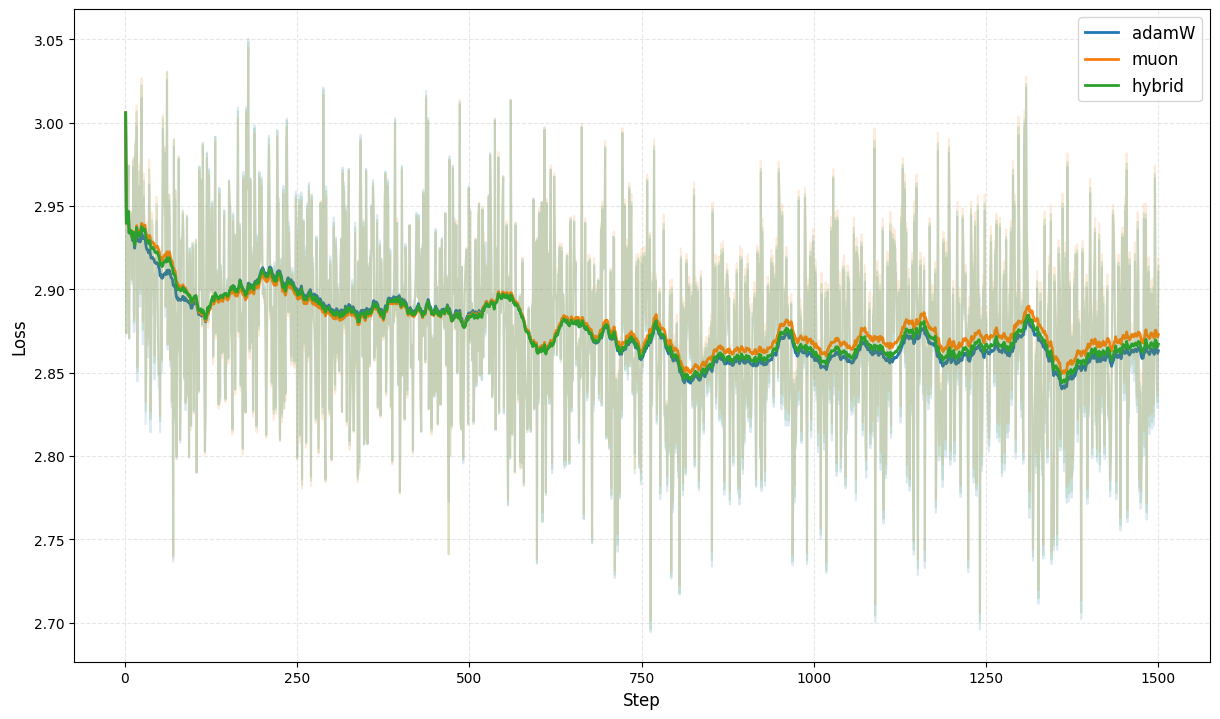

In [83]:
fig